In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
from rich.progress import Progress
from rich.console import Console
import sys
import datetime



df = pd.read_csv('data/testutku.csv')

df.head()

,COMPANY_NAME,PLANT_NAME,EQUIPMENT_CODE,COUNTER_CODE,SHOT_START_TIME,SHOT_END_TIME,CONTRACTED_CYCLE_TIME,CYCLE_TIME_LIMIT1,CYCLE_TIME_LIMIT1UNIT,CYCLE_TIME_LIMIT2,...,WITHIN_COUNT,BELOW_COUNT,ABOVE_AVG_CT,WITHIN_AVG_CT,BELOW_AVG_CT,DAY,MONTH,QUARTER,YEAR,WEEK
0,VT Bulplast,VT Bulplast,6600-025,EMA2324M11974,1716384945000000000,1716388555000000000,11.0,2.0,SECOND,5.0,...,311,0,NaN,12.0,NaN,20240522,202405,20242,2024,202421
1,VT Bulplast,VT Bulplast,6600-025,EMA2324M11974,1716370547000000000,1716374155000000000,11.0,2.0,SECOND,5.0,...,311,0,NaN,12.0,NaN,20240522,202405,20242,2024,202421
2,VT Bulplast,VT Bulplast,6600-025,EMA2324M11974,1716309347000000000,1716312944000000000,11.0,2.0,SECOND,5.0,...,310,0,NaN,12.0,NaN,20240521,202405,20242,2024,202421
3,VT Bulplast,VT Bulplast,6600-025,EMA2324M11974,1716359744000000000,1716363348000000000,11.0,2.0,SECOND,5.0,...,310,0,NaN,12.0,NaN,20240522,202405,20242,2024,202421
4,VT Bulplast,VT Bulplast,6600-025,EMA2324M11974,1716399346000000000,1716402947000000000,11.0,2.0,SECOND,5.0,...,310,0,NaN,12.0,NaN,20240522,202405,20242,2024,202421


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45872 entries, 0 to 45871
Data columns (total 37 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   COMPANY_NAME           45872 non-null  object 
 1   PLANT_NAME             41053 non-null  object 
 2   EQUIPMENT_CODE         41053 non-null  object 
 3   COUNTER_CODE           45872 non-null  object 
 4   SHOT_START_TIME        45872 non-null  int64  
 5   SHOT_END_TIME          45872 non-null  int64  
 6   CONTRACTED_CYCLE_TIME  41053 non-null  float64
 7   CYCLE_TIME_LIMIT1      41053 non-null  float64
 8   CYCLE_TIME_LIMIT1UNIT  41053 non-null  object 
 9   CYCLE_TIME_LIMIT2      41053 non-null  float64
 10  CYCLE_TIME_LIMIT2UNIT  41053 non-null  object 
 11  L2_ABOVE_ADJUSTED      41053 non-null  float64
 12  L2_BELOW_ADJUSTED      41053 non-null  float64
 13  L1_ABOVE_ADJUSTED      41053 non-null  float64
 14  L1_BELOW_ADJUSTED      41053 non-null  float64
 15  ST

In [3]:
ct_per_supplier = df.groupby('COMPANY_NAME')['AVG_VALID_CT'].mean().reset_index()
ct_per_tool = df.groupby('EQUIPMENT_CODE')['AVG_VALID_CT'].mean().reset_index()

print(ct_per_supplier)
print(ct_per_tool)


    COMPANY_NAME  AVG_VALID_CT
0     Plastibell     47.347994
1  Plastiexports     57.511044
2    VT Bulplast     27.359493
3     Wattera Mx     73.189519
    EQUIPMENT_CODE  AVG_VALID_CT
0         0060-017     28.850556
1         0400-251     27.527479
2         0400-252     26.872143
3         0500-003     16.957817
4         0500-005     22.520909
..             ...           ...
109           9857     76.178698
110       BN70-050     25.720476
111           D425     76.770817
112         PL7251     46.573817
113           T655     75.447895

[114 rows x 2 columns]


In [4]:
total_run_time_by_supplier = df.groupby('COMPANY_NAME')['PRODUCTION_TIME'].sum().reset_index()
total_run_time_by_tool = df.groupby('EQUIPMENT_CODE')['PRODUCTION_TIME'].sum().reset_index()

print(total_run_time_by_tool)
print(total_run_time_by_supplier)


    EQUIPMENT_CODE  PRODUCTION_TIME
0         0060-017           177275
1         0400-251           771492
2         0400-252           554021
3         0500-003           849681
4         0500-005           134362
..             ...              ...
109           9857           368578
110       BN70-050          2418091
111           D425          2634023
112         PL7251           232815
113           T655          1568710

[114 rows x 2 columns]
    COMPANY_NAME  PRODUCTION_TIME
0     Plastibell         25235621
1  Plastiexports         22529862
2    VT Bulplast         96683281
3     Wattera Mx          4436825


In [5]:
uptime_per_supplier = df.groupby('COMPANY_NAME')['UPTIME_PERCENTAGE'].mean().reset_index()
uptime_per_tool = df.groupby('EQUIPMENT_CODE')['UPTIME_PERCENTAGE'].mean().reset_index()

print(uptime_per_supplier)
print(uptime_per_tool)


    COMPANY_NAME  UPTIME_PERCENTAGE
0     Plastibell          89.126778
1  Plastiexports          88.565617
2    VT Bulplast          95.857089
3     Wattera Mx          90.578976
    EQUIPMENT_CODE  UPTIME_PERCENTAGE
0         0060-017          96.092407
1         0400-251          94.536074
2         0400-252          95.779583
3         0500-003          96.245556
4         0500-005          95.652955
..             ...                ...
109           9857          59.228542
110       BN70-050          94.965476
111           D425          92.996951
112         PL7251          63.906870
113           T655          93.850445

[114 rows x 2 columns]


In [6]:
shot_count_per_supplier = df.groupby('COMPANY_NAME')['SHOT_COUNT'].sum().reset_index()
shot_count_per_tool = df.groupby('EQUIPMENT_CODE')['SHOT_COUNT'].sum().reset_index()

print(shot_count_per_supplier)
print(shot_count_per_tool)

    COMPANY_NAME  SHOT_COUNT
0     Plastibell      908399
1  Plastiexports      532961
2    VT Bulplast     4262550
3     Wattera Mx       69932
    EQUIPMENT_CODE  SHOT_COUNT
0         0060-017        6496
1         0400-251       32786
2         0400-252       25614
3         0500-003       53408
4         0500-005        7969
..             ...         ...
109           9857        9837
110       BN70-050      105762
111           D425       38051
112         PL7251        8696
113           T655       23029

[114 rows x 2 columns]


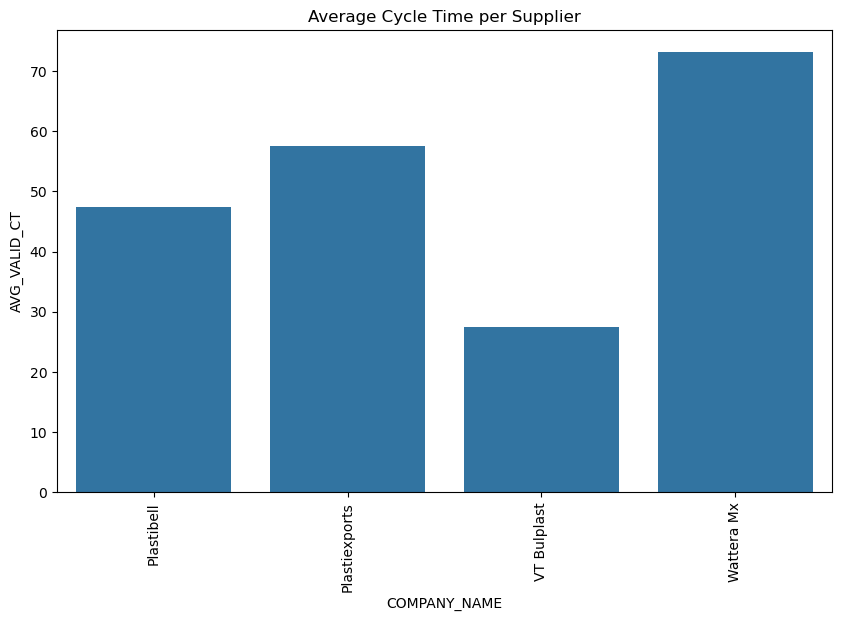

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: Average Cycle Time per Supplier
plt.figure(figsize=(10, 6))
sns.barplot(x='COMPANY_NAME', y='AVG_VALID_CT', data=ct_per_supplier)
plt.title('Average Cycle Time per Supplier')
plt.xticks(rotation=90)
plt.show()


In [8]:
import plotly.express as px

# Average Cycle Time per Supplier
fig = px.pie(ct_per_supplier, 
             names='COMPANY_NAME', 
             values='AVG_VALID_CT',
             title='Average Cycle Time per Supplier',
             color='COMPANY_NAME',  # Adding color differentiation
             hole=0.3)  # Makes it a donut chart

# Show the chart
fig.update_traces(textinfo='percent+label')  # Show percentage and label
fig.show()


In [9]:
import plotly.express as px
# Round AVG_VALID_CT to 2 decimal places
ct_per_supplier['AVG_VALID_CT'] = ct_per_supplier['AVG_VALID_CT'].round(2)

# Example: Average Cycle Time per Supplier
fig = px.bar(ct_per_supplier, 
             x='COMPANY_NAME', 
             y='AVG_VALID_CT',
             title='Average Cycle Time per Supplier',
             color='COMPANY_NAME',  # Color based on company
             labels={'AVG_VALID_CT': 'Average Cycle Time (seconds)', 'COMPANY_NAME': 'Supplier'},
             text='AVG_VALID_CT')  # Display the value on top of the bars

# Customize layout
fig.update_layout(xaxis_title='Supplier',
                  yaxis_title='Average Cycle Time (sec)',
                  showlegend=False)

# Show the chart
fig.show()


In [10]:
# Calculate key metrics for ranking
supplier_metrics = df.groupby('COMPANY_NAME').agg(
    avg_cycle_time=('AVG_VALID_CT', 'mean'),
    avg_uptime_percentage=('UPTIME_PERCENTAGE', 'mean'),
    total_shot_count=('SHOT_COUNT', 'sum')
).reset_index()

# Normalize metrics (between 0 and 1) for comparison purposes
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
supplier_metrics[['avg_cycle_time', 'avg_uptime_percentage', 'total_shot_count']] = scaler.fit_transform(
    supplier_metrics[['avg_cycle_time', 'avg_uptime_percentage', 'total_shot_count']])

# Combine metrics into an overall score, you may want to weight them differently
# Lower cycle time and higher uptime and shot count are better, so we'll invert avg_cycle_time
supplier_metrics['overall_score'] = supplier_metrics['avg_uptime_percentage'] + supplier_metrics['total_shot_count'] - supplier_metrics['avg_cycle_time']

# Rank suppliers based on overall score
supplier_metrics['rank'] = supplier_metrics['overall_score'].rank(ascending=False)

# Display top 10 suppliers
top_suppliers = supplier_metrics.sort_values(by='rank').head(10)
print(top_suppliers[['COMPANY_NAME', 'rank', 'overall_score']])



    COMPANY_NAME  rank  overall_score
2    VT Bulplast   1.0       2.000000
0     Plastibell   2.0      -0.159196
1  Plastiexports   3.0      -0.547460
3     Wattera Mx   4.0      -0.723875


In [11]:
# Find suppliers or tools with high cycle times, low uptime, and low shot counts
bottleneck_thresholds = {
    'avg_cycle_time': supplier_metrics['avg_cycle_time'].quantile(0.75),  # Top 25% higher cycle times means bottlenecks
    'avg_uptime_percentage': supplier_metrics['avg_uptime_percentage'].quantile(0.25),  # Bottom 25% lower uptime means bottlenecks
    'total_shot_count': supplier_metrics['total_shot_count'].quantile(0.25)  # Bottom 25% low shot counts means also bottlenecks
}

# Identify bottlenecks based on thresholds
bottlenecks = supplier_metrics[
    (supplier_metrics['avg_cycle_time'] > bottleneck_thresholds['avg_cycle_time']) |
    (supplier_metrics['avg_uptime_percentage'] < bottleneck_thresholds['avg_uptime_percentage']) |
    (supplier_metrics['total_shot_count'] < bottleneck_thresholds['total_shot_count'])
]

print(bottlenecks[['COMPANY_NAME', 'avg_cycle_time', 'avg_uptime_percentage', 'total_shot_count']])


    COMPANY_NAME  avg_cycle_time  avg_uptime_percentage  total_shot_count
1  Plastiexports        0.657899               0.000000          0.110439
3     Wattera Mx        1.000000               0.276125          0.000000


In [27]:
import pandas as pd

# Assuming df is your original DataFrame
df['START_TIME'] = pd.to_datetime(df['START_TIME'])
df['month'] = df['START_TIME'].dt.to_period('M').astype(str)

# Remove duplicates for the same COMPANY_NAME and month (aggregating or dropping duplicates)
df = df.drop_duplicates(subset=['COMPANY_NAME', 'month'], keep='first')  # or use aggregation if necessary

# Create a list of all months in 2024
all_months = pd.date_range('2024-01-01', '2024-12-01', freq='MS').strftime('%Y-%m')

# Generate all combinations of COMPANY_NAME and month
company_months = pd.MultiIndex.from_product(
    [df['COMPANY_NAME'].unique(), all_months],
    names=['COMPANY_NAME', 'month']
)

# Reindex the original DataFrame to include all months for each company
df = df.set_index(['COMPANY_NAME', 'month']).reindex(company_months, fill_value=None).reset_index()

# Group by supplier and get the monthly average cycle time, uptime, and shot count
monthly_performance = df.groupby(['COMPANY_NAME', 'month']).agg(
    avg_cycle_time=('AVG_VALID_CT', 'mean'),
    avg_uptime_percentage=('UPTIME_PERCENTAGE', 'mean'),
    total_shot_count=('SHOT_COUNT', 'sum')
).reset_index()

# Apply rolling mean with a window size of 6 months
monthly_performance['avg_cycle_time_forecast'] = monthly_performance.groupby('COMPANY_NAME')['avg_cycle_time'].transform(lambda x: x.rolling(window=6, min_periods=1).mean())

# Sort the data by COMPANY_NAME and month for correct chronological order
monthly_performance['month'] = pd.to_datetime(monthly_performance['month'])
monthly_performance = monthly_performance.sort_values(by=['COMPANY_NAME', 'month'])

# Show the results after filling in missing months
print(monthly_performance[['COMPANY_NAME', 'month', 'avg_cycle_time_forecast', 'avg_uptime_percentage', 'total_shot_count']])


     COMPANY_NAME      month  avg_cycle_time_forecast  avg_uptime_percentage  \
0      Plastibell 2024-01-01                      NaN                    NaN   
1      Plastibell 2024-02-01                      NaN                    NaN   
2      Plastibell 2024-03-01                      NaN                    NaN   
3      Plastibell 2024-04-01                      NaN                    NaN   
4      Plastibell 2024-05-01                      NaN                    NaN   
5      Plastibell 2024-06-01                 3.500000                 100.00   
6      Plastibell 2024-07-01                27.750000                  57.78   
7      Plastibell 2024-08-01                36.853333                  71.85   
8      Plastibell 2024-09-01                38.140000                  98.85   
9      Plastibell 2024-10-01                32.912000                  99.67   
10     Plastibell 2024-11-01                33.260000                  99.03   
11     Plastibell 2024-12-01            

Month range in the dataset:
2024-01 to 2024-12


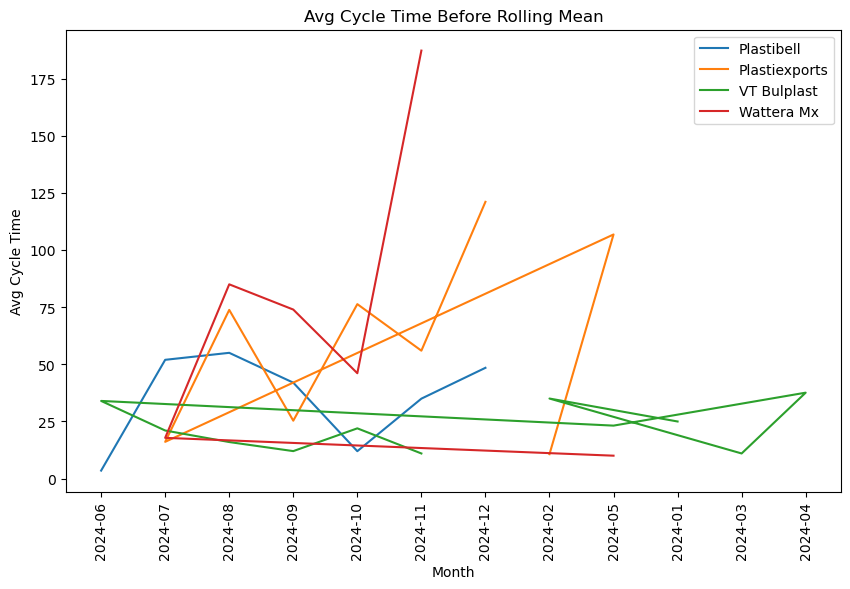

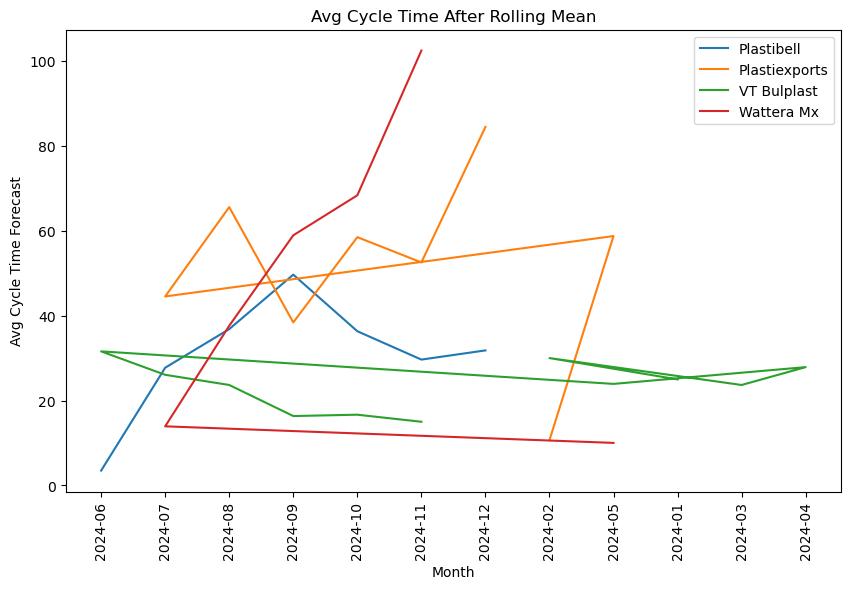

     COMPANY_NAME    month  avg_cycle_time_forecast  avg_uptime_percentage  \
6      Plastibell  2024-12                31.833333                  91.86   
14  Plastiexports  2024-12                84.513333                  64.12   

    total_shot_count  
6               12.0  
14              36.0  


In [32]:

# Convert 'START_TIME' to datetime and ensure correct format
df['START_TIME'] = pd.to_datetime(df['START_TIME'], errors='coerce')  # Convert, invalid formats will become NaT

# Remove rows where 'START_TIME' could not be converted (NaT values)
df = df.dropna(subset=['START_TIME'])

# Sort the data by 'START_TIME' in ascending order
df = df.sort_values(by=['COMPANY_NAME', 'START_TIME'])

# Create a 'month' column for time series analysis (period format)
df['month'] = df['START_TIME'].dt.to_period('M')

# Group by supplier and get the monthly average cycle time, uptime, and shot count
monthly_performance = df.groupby(['COMPANY_NAME', 'month']).agg(
    avg_cycle_time=('AVG_VALID_CT', 'mean'),
    avg_uptime_percentage=('UPTIME_PERCENTAGE', 'mean'),
    total_shot_count=('SHOT_COUNT', 'sum')
).reset_index()

# Ensure the avg_cycle_time column is numeric (in case of non-numeric values)
monthly_performance['avg_cycle_time'] = pd.to_numeric(monthly_performance['avg_cycle_time'], errors='coerce')

# Display the range of months in the dataset
print("Month range in the dataset:")
print(df['month'].min(), "to", df['month'].max())

import matplotlib.pyplot as plt

# Visualize the 'avg_cycle_time' before applying rolling mean
plt.figure(figsize=(10, 6))
for company in monthly_performance['COMPANY_NAME'].unique():
    company_data = monthly_performance[monthly_performance['COMPANY_NAME'] == company]
    plt.plot(company_data['month'].astype(str), company_data['avg_cycle_time'], label=company)
plt.title('Avg Cycle Time Before Rolling Mean')
plt.xlabel('Month')
plt.ylabel('Avg Cycle Time')
plt.xticks(rotation=90)
plt.legend()
plt.show()

# Apply rolling mean with a window size of 6 months
monthly_performance['avg_cycle_time_forecast'] = monthly_performance.groupby('COMPANY_NAME')['avg_cycle_time'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

# Visualize the rolling average (forecast) to see changes
plt.figure(figsize=(10, 6))
for company in monthly_performance['COMPANY_NAME'].unique():
    company_data = monthly_performance[monthly_performance['COMPANY_NAME'] == company]
    plt.plot(company_data['month'].astype(str), company_data['avg_cycle_time_forecast'], label=company)
plt.title('Avg Cycle Time After Rolling Mean')
plt.xlabel('Month')
plt.ylabel('Avg Cycle Time Forecast')
plt.xticks(rotation=90)
plt.legend()
plt.show()


# Show the forecasted values for the most recent month
forecasted_data = monthly_performance[monthly_performance['month'] == monthly_performance['month'].max()]

# Display the forecasted data
print(forecasted_data[['COMPANY_NAME', 'month', 'avg_cycle_time_forecast', 'avg_uptime_percentage', 'total_shot_count']])


In [33]:
import dash
from dash import dcc, html
import plotly.graph_objs as go
import pandas as pd
import dash_bootstrap_components as dbc


# Creating the Dash app
app = dash.Dash(__name__, external_stylesheets=[dbc.themes.BOOTSTRAP])

# Supplier Ranking Bar Chart (Ranking based on Uptime %)
def create_supplier_ranking_chart():
    # Sort suppliers by Uptime Percentage
    supplier_ranking = df.groupby('COMPANY_NAME').agg({'UPTIME_PERCENTAGE': 'mean'}).reset_index()
    supplier_ranking = supplier_ranking.sort_values(by='UPTIME_PERCENTAGE', ascending=False)

    # Create Bar chart
    trace = go.Bar(
        x=supplier_ranking['COMPANY_NAME'],
        y=supplier_ranking['UPTIME_PERCENTAGE'],
        name="Uptime Percentage",
        marker=dict(color='rgb(55, 83, 109)'),
    )
    layout = go.Layout(
        title='Supplier Ranking Based on Uptime Percentage',
        xaxis=dict(title='Supplier'),
        yaxis=dict(title='Uptime Percentage'),
        showlegend=False
    )
    return {'data': [trace], 'layout': layout}

# Bottleneck Suppliers Scatter Plot (based on Cycle Time vs Uptime % vs Shot Count)
def create_bottleneck_chart():
    # Use the data directly for plotting
    trace = go.Scatter(
        x=df['CONTRACTED_CYCLE_TIME'],
        y=df['UPTIME_PERCENTAGE'],
        mode='markers',
        text=df['COMPANY_NAME'],
        marker=dict(
            size=df['SHOT_COUNT'], 
            color=df['SHOT_COUNT'], 
            colorscale='Viridis', 
            showscale=True
        )
    )
    layout = go.Layout(
        title='Bottleneck Suppliers Based on Cycle Time, Uptime, and Shot Count',
        xaxis=dict(title='Cycle Time'),
        yaxis=dict(title='Uptime Percentage'),
        showlegend=False
    )
    return {'data': [trace], 'layout': layout}

# Forecasting Performance Trend (Simple Trend Line for Uptime % over months)
def create_forecasting_chart():
    # Example: Uptime % trend over time (monthly)
    monthly_performance = df.groupby('MONTH').agg({'UPTIME_PERCENTAGE': 'mean'}).reset_index()
    
    trace = go.Scatter(
        x=monthly_performance['MONTH'],
        y=monthly_performance['UPTIME_PERCENTAGE'],
        mode='lines+markers',
        name='Monthly Uptime Percentage',
    )
    layout = go.Layout(
        title='Forecasted Uptime Performance Trend (Monthly)',
        xaxis=dict(title='Month'),
        yaxis=dict(title='Uptime Percentage'),
    )
    return {'data': [trace], 'layout': layout}

# Layout
app.layout = html.Div([
    # Title
    html.H1("Sales Team Dashboard", style={'textAlign': 'center'}),

    # Supplier Ranking Bar Chart
    html.Div([
        html.H3("Supplier Ranking Based on Uptime Percentage"),
        dcc.Graph(id='supplier-ranking-chart', figure=create_supplier_ranking_chart())
    ]),

    # Bottleneck Suppliers Scatter Plot
    html.Div([
        html.H3("Bottleneck Suppliers Based on Cycle Time, Uptime, and Shot Count"),
        dcc.Graph(id='bottleneck-chart', figure=create_bottleneck_chart())
    ]),

    # Forecasting Performance Trend
    html.Div([
        html.H3("Forecasted Performance Trend"),
        dcc.Graph(id='forecasting-chart', figure=create_forecasting_chart())
    ]),
])

# Run the app
if __name__ == '__main__':
    app.run_server(debug=True)
